# Phase 2 — Étude exploratoire de l'engagement Instagram

Objectif : comprendre ce qui fait varier l'engagement d'un post **avant** de modéliser,
et identifier les pièges du jeu de données.

## Définitions

`taux_engagement = (likes + commentaires) / followers × 100`

## Périmètre

L'analyse ne porte que sur les posts dont les likes sont **visibles**. L'API Instagram
masque le compteur de likes sur certains comptes ; ces posts n'ont pas de cible
exploitable et sont écartés. Mon compte personnel est également exclu : il sert de
cas d'usage final, pas d'exemple d'entraînement.

## Deux biais à garder en tête

1. **Followers figés.** L'API ne donne que le nombre d'abonnés *aujourd'hui*, alors que
   les posts s'étalent de 2013 à 2026. Un compte qui a beaucoup grandi voit ses vieux
   posts pénalisés : ils ont été vus par une audience réduite mais sont divisés par
   l'audience actuelle. Toute tendance temporelle mesure donc en partie la croissance
   du compte, pas la qualité du contenu.
2. **Heures en UTC.** L'API horodate en UTC et les comptes sont dans plusieurs pays.
   Les heures de publication ne correspondent donc pas à l'heure locale de l'audience.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from src.viz.style import (INK, THEMES, TYPES_POST, appliquer_style,
                           couleurs_theme, couleurs_type, etiqueter_barres, finir)

MODE = "light"
ink = appliquer_style(MODE)
C_THEME, C_TYPE = couleurs_theme(MODE), couleurs_type(MODE)

df = pd.read_csv(RACINE / "data/processed/dataset_clean.csv", parse_dates=["timestamp"])
u = df[df.utilisable_entrainement].copy()   # posts exploitables
print(f"{len(df)} posts collectes -> {len(u)} exploitables ({u.compte.nunique()} comptes)")

4173 posts collectes -> 3587 exploitables (28 comptes)


---
## 1. Distribution de l'engagement

C'est le point de départ obligatoire : la forme de la distribution décide de tout
le reste (quelle statistique citer, quelle échelle utiliser, quelle métrique
d'erreur choisir au moment de modéliser).

In [2]:
desc = u.taux_engagement.describe(percentiles=[.05, .25, .5, .75, .95, .99])
print(desc.round(2).to_string())
print(f"\nposts au-dessus de 100 % : {(u.taux_engagement > 100).sum()} ({(u.taux_engagement > 100).mean() * 100:.1f} %)")
print(f"ecart moyenne / mediane : {u.taux_engagement.mean():.1f} % vs {u.taux_engagement.median():.2f} %")

count     3587.00
mean        30.40
std        301.23
min          0.00
5%           0.29
25%          1.21
50%          3.26
75%          9.78
95%         40.04
99%        464.72
max      11077.35

posts au-dessus de 100 % : 94 (2.6 %)
ecart moyenne / mediane : 30.4 % vs 3.26 %


La moyenne (30,4 %) est presque dix fois la médiane (3,3 %). La distribution est donc
très asymétrique à droite : une poignée de posts viraux tire la moyenne vers le haut.

**Conséquence n°1 : on raisonne en médiane dans tout ce notebook.** La moyenne décrirait
surtout les valeurs extrêmes.

Un taux supérieur à 100 % n'est pas une anomalie : un reel peut être vu bien au-delà
des abonnés du compte, donc récolter plus de likes que le compte n'a de followers.
2,6 % des posts sont dans ce cas.

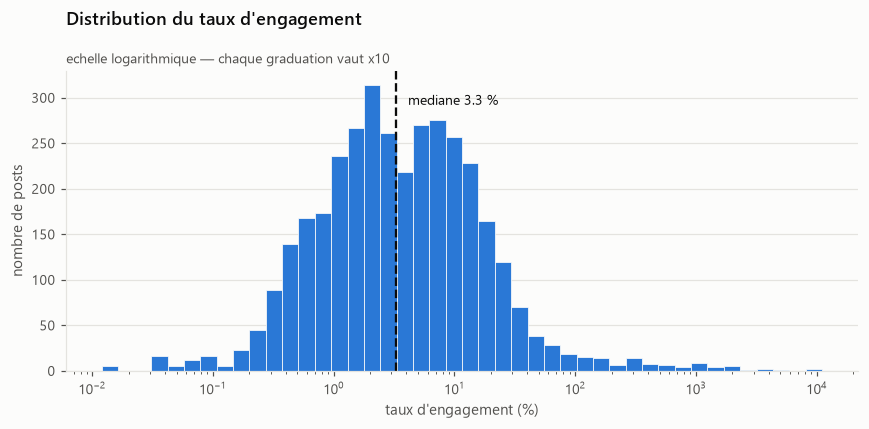

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
positifs = u.taux_engagement[u.taux_engagement > 0]
bins = np.logspace(np.log10(positifs.min()), np.log10(positifs.max()), 45)
ax.hist(positifs, bins=bins, color=C_THEME["art"], edgecolor=ink["surface"], linewidth=0.5)
ax.set_xscale("log")

med = u.taux_engagement.median()
ax.axvline(med, color=ink["primary"], linestyle="--", linewidth=1.5)
ax.annotate(f"mediane {med:.1f} %", (med, ax.get_ylim()[1] * 0.92),
            xytext=(8, 0), textcoords="offset points",
            color=ink["primary"], fontsize=9, va="top")

finir(ax, "Distribution du taux d'engagement",
      "echelle logarithmique — chaque graduation vaut x10",
      "nombre de posts", "taux d'engagement (%)", MODE)
plt.tight_layout(); plt.show()

L'échelle logarithmique est indispensable : en échelle linéaire, 97 % des posts
s'écraseraient dans la première barre. La forme obtenue est proche d'une log-normale.

**Conséquence n°2 : il faudra modéliser le logarithme de l'engagement**, sinon quelques
posts viraux domineront l'erreur d'apprentissage.

C:\Users\wiamh\AppData\Local\Temp\ipykernel_5716\3678786241.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(donnees, vert=True, patch_artist=True, showfliers=False,


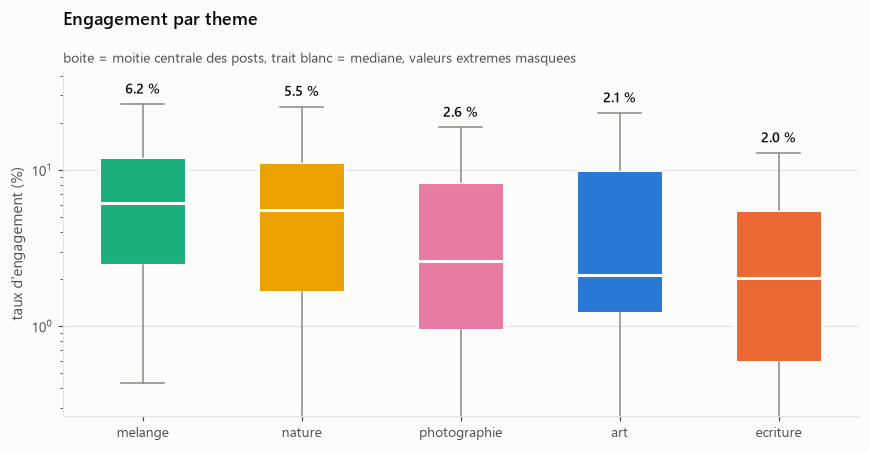

              posts  mediane    q1     q3
theme                                    
art             856     2.12  1.21   9.97
ecriture        608     2.04  0.59   5.52
melange         432     6.18  2.47  12.09
nature          899     5.52  1.66  11.30
photographie    792     2.61  0.95   8.34


In [4]:
ordre = u.groupby("theme").taux_engagement.median().sort_values(ascending=False).index.tolist()
donnees = [u.loc[u.theme == t, "taux_engagement"].values for t in ordre]

fig, ax = plt.subplots(figsize=(8, 4.2))
bp = ax.boxplot(donnees, vert=True, patch_artist=True, showfliers=False,
                widths=0.55, medianprops=dict(color=ink["surface"], linewidth=2),
                whiskerprops=dict(color=ink["muted"]), capprops=dict(color=ink["muted"]))
for boite, t in zip(bp["boxes"], ordre):
    boite.set(facecolor=C_THEME[t], edgecolor=ink["surface"], linewidth=2)

ax.set_yscale("log")
ax.set_xticks(range(1, len(ordre) + 1)); ax.set_xticklabels(ordre)

# Etiquettes de valeurs : obligatoires, trois teintes passent sous 3:1 en mode clair.
# Posees au-dessus de la moustache haute pour ne pas se poser sur l'aplat de couleur.
for i, t in enumerate(ordre, start=1):
    m = u.loc[u.theme == t, "taux_engagement"].median()
    haut = bp["caps"][2 * i - 1].get_ydata()[0]
    ax.annotate(f"{m:.1f} %", (i, haut), xytext=(0, 7), textcoords="offset points",
                ha="center", fontsize=9, color=ink["primary"], fontweight="semibold")
ax.margins(y=0.12)

finir(ax, "Engagement par theme",
      "boite = moitie centrale des posts, trait blanc = mediane, valeurs extremes masquees",
      "taux d'engagement (%)", None, MODE)
plt.tight_layout(); plt.show()

print(u.groupby("theme").taux_engagement.agg(
    posts="count", mediane="median",
    q1=lambda s: s.quantile(.25), q3=lambda s: s.quantile(.75)).round(2).to_string())

Les thèmes se séparent en deux groupes : **mélange (6,2 %) et nature (5,5 %)** devant
**photographie (2,6 %), art (2,1 %) et écriture (2,0 %)**, soit un rapport de 3 entre
les extrêmes.

Attention à l'interprétation : les boîtes se chevauchent largement. Le thème décale la
distribution, il ne la détermine pas. Et comme on le verra en partie 4, les thèmes ne
regroupent pas des comptes de taille comparable, ce qui brouille la lecture.

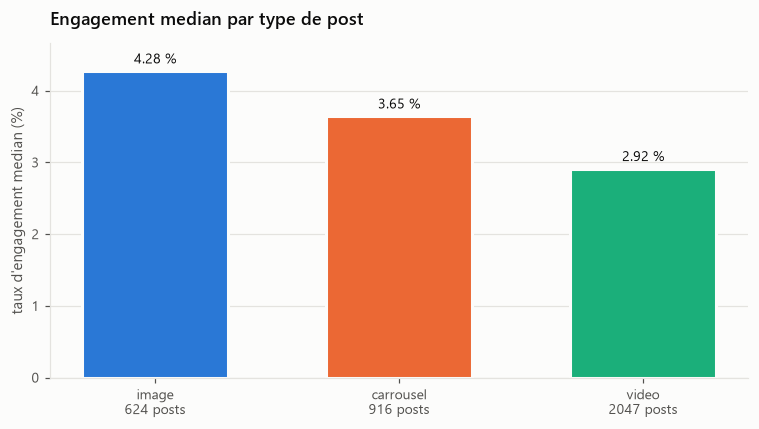

           posts  mediane  moyenne
type_post                         
image        624     4.28    11.69
carrousel    916     3.65    11.29
video       2047     2.92    44.65

Kruskal-Wallis : p = 6.03e-09


In [5]:
stat = u.groupby("type_post").taux_engagement.agg(
    posts="count", mediane="median", moyenne="mean").reindex(TYPES_POST)
x = np.arange(len(TYPES_POST))

fig, ax = plt.subplots(figsize=(7, 4))
barres = ax.bar(x, stat.mediane, width=0.6,
                color=[C_TYPE[t] for t in TYPES_POST],
                edgecolor=ink["surface"], linewidth=2)
etiqueter_barres(ax, barres, stat.mediane.values, "{:.2f} %", MODE)
ax.set_xticks(x)
ax.set_xticklabels([f"{t}\n{int(n)} posts" for t, n in zip(TYPES_POST, stat.posts)])

finir(ax, "Engagement median par type de post", None, "taux d'engagement median (%)", None, MODE)
plt.tight_layout(); plt.show()

print(stat.round(2).to_string())
p = stats.kruskal(*[g.taux_engagement.values for _, g in u.groupby("type_post")]).pvalue
print(f"\nKruskal-Wallis : p = {p:.2e}")

Résultat contre-intuitif : la **vidéo a la médiane la plus basse (2,9 %)**, derrière
l'image fixe (4,3 %) et le carrousel (3,7 %). L'écart est statistiquement net
(p < 10⁻⁸).

Mais la moyenne raconte l'inverse : **44,7 % pour la vidéo contre 11,7 % pour l'image**.
Autrement dit, la vidéo se comporte comme un billet de loterie. La plupart des reels
font moins bien qu'une photo, mais ce sont eux qui produisent tous les cartons.

C'est une distinction utile pour un créateur : la vidéo augmente l'espérance de gain
tout en abaissant le résultat le plus probable.

---
## 2. Texte de la légende (NLP préliminaire)

On teste ici les recettes que tout le monde répète : écrire long, empiler les hashtags,
mettre des emojis. On utilise la corrélation de Spearman, qui mesure un lien
monotone par les rangs, sans supposer une relation linéaire — adapté à une
distribution aussi asymétrique.

In [6]:
lignes = []
for col, label in [("longueur_legende", "longueur (caracteres)"),
                   ("nb_mots_legende", "nombre de mots"),
                   ("nb_hashtags", "nombre de hashtags"),
                   ("nb_emojis", "nombre d'emojis"),
                   ("nb_mentions", "nombre de mentions")]:
    rho, p = stats.spearmanr(u[col], u.taux_engagement)
    lignes.append({"variable": label, "rho": round(rho, 3), "p": p,
                   "significatif": "oui" if p < 0.05 else "non"})
print(pd.DataFrame(lignes).to_string(index=False))

             variable    rho            p significatif
longueur (caracteres)  0.101 1.225778e-09          oui
       nombre de mots  0.100 1.618356e-09          oui
   nombre de hashtags -0.009 5.782592e-01          non
      nombre d'emojis -0.001 9.426241e-01          non
   nombre de mentions -0.005 7.441567e-01          non


Seule la longueur de la légende ressort (rho = +0,10, p < 10⁻⁸), et l'effet est
minuscule : rho = 0,10 signifie qu'environ **1 % de la variation d'engagement** est liée
à la longueur du texte.

Le nombre de hashtags affiche rho = −0,009 (p = 0,58), les emojis rho = −0,001. Il est
tentant d'en conclure « aucun effet », mais ce serait une erreur de lecture :
**Spearman ne détecte que les relations monotones**. Un effet en cloche — quelques
hashtags aident, beaucoup nuisent — donnerait exactement ce rho nul. La cellule
suivante teste donc par tranches plutôt que par corrélation.

In [7]:
TRANCHES = [-1, 0, 5, 10, 20, 100]
NOMS = ["0", "1-5", "6-10", "11-20", "21+"]
u["tranche_ht"] = pd.cut(u.nb_hashtags, TRANCHES, labels=NOMS)

# Un compte publie avec ses habitudes ET son niveau d'engagement propre. On rapporte
# donc chaque post a la mediane de son compte, pour isoler l'effet des hashtags.
u["engagement_relatif"] = (u.taux_engagement
                           / u.groupby("compte").taux_engagement.transform("median"))

bilan = u.groupby("tranche_ht", observed=True).agg(
    posts=("id", "count"),
    mediane_brute=("taux_engagement", "median"),
    relatif=("engagement_relatif", "median")).round(3)
print(bilan.to_string())

p_brut = stats.kruskal(*[g.taux_engagement.values
                         for _, g in u.groupby("tranche_ht", observed=True)]).pvalue
p_rel = stats.kruskal(*[g.engagement_relatif.values
                        for _, g in u.groupby("tranche_ht", observed=True)]).pvalue
print(f"\nKruskal-Wallis brut     : p = {p_brut:.2e}")
print(f"Kruskal-Wallis relatif  : p = {p_rel:.2e}  (effet de compte neutralise)")

            posts  mediane_brute  relatif
tranche_ht                               
0             946          2.867    0.915
1-5          1690          4.730    1.091
6-10          391          1.824    0.952
11-20         380          2.876    0.969
21+           180          1.818    0.957

Kruskal-Wallis brut     : p = 1.56e-32
Kruskal-Wallis relatif  : p = 5.14e-11  (effet de compte neutralise)


Le découpage par tranches révèle ce que la corrélation masquait, et l'effet **survit au
contrôle par compte** : rapportés au niveau habituel de leur propre compte, les posts
portant **1 à 5 hashtags font 9 % de mieux** (ratio 1,09), tandis que ceux sans hashtag
(0,92) ou avec 6 et plus (0,95 à 0,97) font légèrement moins bien.

Deux précautions de lecture s'imposent. D'abord, l'ordre de grandeur : ±10 % autour du
niveau du compte, à comparer au facteur 4,5 de l'heure de publication. Ensuite, le
sens : **rien n'indique qu'ajouter des hashtags cause un meilleur engagement.** Un post
soigné a des chances de recevoir à la fois une légende travaillée avec quelques hashtags
pertinents et un meilleur accueil, sans que l'un produise l'autre.

La conclusion honnête est donc : *empiler les hashtags n'apporte rien au-delà de cinq*,
et non *les hashtags ne servent à rien*.

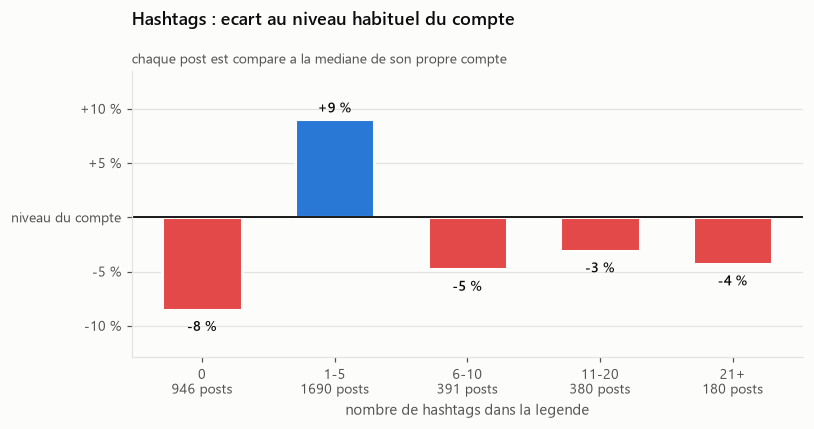

In [8]:
from src.viz.style import DIVERGENT

bilan_ord = bilan.reindex(NOMS)
ecart = bilan_ord.relatif - 1.0      # ecart au niveau du compte, en points de ratio
div = DIVERGENT[MODE]

# Barres d'ecart ancrees a 1,00 : la longueur encode le depassement, pas une valeur
# absolue. Un axe tronque sous des barres partant de zero exagererait l'effet.
fig, ax = plt.subplots(figsize=(7.5, 4))
barres = ax.bar(range(len(NOMS)), ecart, width=0.6,
                color=[div["pos"] if e >= 0 else div["neg"] for e in ecart],
                edgecolor=ink["surface"], linewidth=2)
ax.axhline(0, color=ink["primary"], linewidth=1.2)
for barre, e in zip(barres, ecart):
    ax.annotate(f"{e * 100:+.0f} %", (barre.get_x() + barre.get_width() / 2, e),
                xytext=(0, 4 if e >= 0 else -14), textcoords="offset points",
                ha="center", fontsize=9, color=ink["primary"], fontweight="semibold")
ax.set_xticks(range(len(NOMS)))
ax.set_xticklabels([f"{t}\n{int(n)} posts" for t, n in zip(NOMS, bilan_ord.posts)])
ax.set_yticks([-0.10, -0.05, 0, 0.05, 0.10])
ax.set_yticklabels(["-10 %", "-5 %", "niveau du compte", "+5 %", "+10 %"])
ax.margins(y=0.25)
finir(ax, "Hashtags : ecart au niveau habituel du compte",
      "chaque post est compare a la mediane de son propre compte",
      None, "nombre de hashtags dans la legende", MODE)
plt.tight_layout(); plt.show()

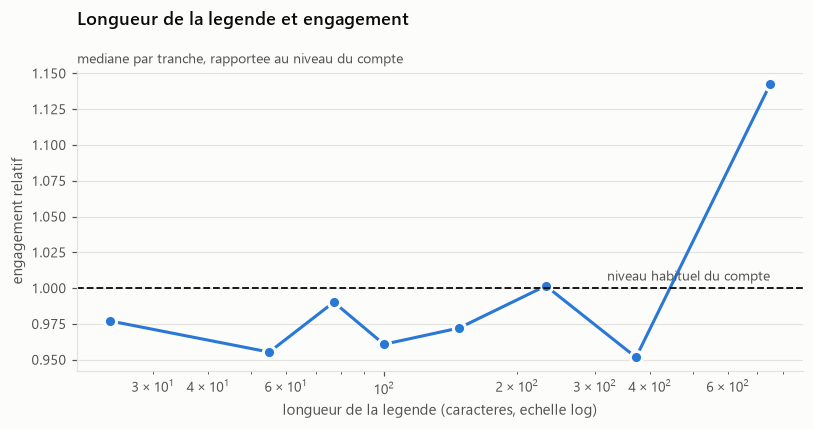

In [9]:
tranches = pd.qcut(u.longueur_legende, 8, duplicates="drop")
g = u.groupby(tranches, observed=True).agg(
    med=("engagement_relatif", "median"), n=("id", "count"),
    centre=("longueur_legende", "median"))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(g.centre, g.med, color=C_THEME["art"], marker="o", markersize=8,
        markeredgecolor=ink["surface"], markeredgewidth=2)
ax.axhline(1.0, color=ink["primary"], linestyle="--", linewidth=1.2)
ax.annotate("niveau habituel du compte", (g.centre.iloc[-1], 1.0), xytext=(0, 5),
            textcoords="offset points", ha="right", fontsize=9, color=ink["secondary"])
ax.set_xscale("log")
finir(ax, "Longueur de la legende et engagement",
      "mediane par tranche, rapportee au niveau du compte",
      "engagement relatif", "longueur de la legende (caracteres, echelle log)", MODE)
plt.tight_layout(); plt.show()

Rapportée au niveau de chaque compte, la longueur de légende dessine une pente douce et
régulière : les légendes les plus longues dépassent légèrement le niveau habituel de
leur compte. C'est cohérent avec le rho positif mais faible mesuré plus haut, et cela
reste, là encore, une association et non une preuve d'effet.

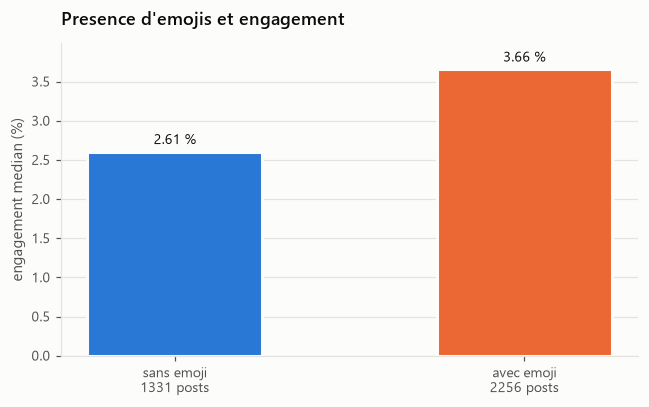

Mann-Whitney U : p = 0.247
-> ecart NON significatif


In [10]:
groupes = [("sans emoji", u[~u.a_emoji]), ("avec emoji", u[u.a_emoji])]
med = [g.taux_engagement.median() for _, g in groupes]
n = [len(g) for _, g in groupes]

fig, ax = plt.subplots(figsize=(6, 3.8))
barres = ax.bar(range(2), med, width=0.5,
                color=[C_TYPE["image"], C_TYPE["carrousel"]],
                edgecolor=ink["surface"], linewidth=2)
etiqueter_barres(ax, barres, med, "{:.2f} %", MODE)
ax.set_xticks(range(2))
ax.set_xticklabels([f"{lab}\n{k} posts" for (lab, _), k in zip(groupes, n)])
finir(ax, "Presence d'emojis et engagement", None, "engagement median (%)", None, MODE)
plt.tight_layout(); plt.show()

test = stats.mannwhitneyu(u[u.a_emoji].taux_engagement, u[~u.a_emoji].taux_engagement)
print(f"Mann-Whitney U : p = {test.pvalue:.3f}")
print(f"-> {'ecart significatif' if test.pvalue < 0.05 else 'ecart NON significatif'}")

L'écart apparent (3,66 % avec emoji contre 2,61 % sans) **n'est pas statistiquement
significatif** (p = 0,25). Avec 3 587 posts, si l'effet était réel il serait détecté.

C'est un bon rappel méthodologique : un écart de médianes visible à l'œil ne suffit pas,
il faut le tester avant d'en tirer une recommandation.

---
## 3. Analyse temporelle

Les heures sont en UTC, pas en heure locale de l'audience. Les écarts observés mélangent
donc l'effet « bon moment pour publier » et l'effet « fuseau horaire du compte ».

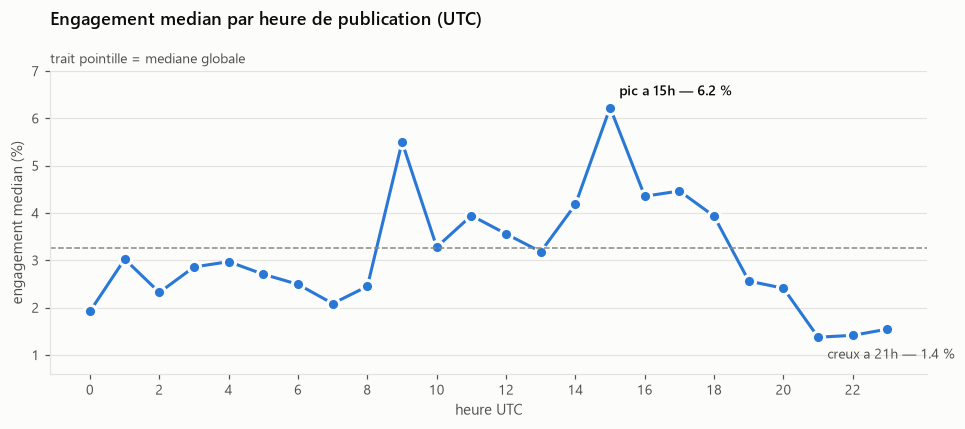

Kruskal-Wallis sur l'heure : p = 1.36e-14


In [11]:
h = u.groupby("heure").taux_engagement.agg(med="median", n="count")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(h.index, h.med, color=C_THEME["art"], marker="o", markersize=8,
        markeredgecolor=ink["surface"], markeredgewidth=2, solid_capstyle="round")
ax.axhline(u.taux_engagement.median(), color=ink["muted"], linestyle="--", linewidth=1)

pic = h.med.idxmax()
ax.annotate(f"pic a {pic}h — {h.med.max():.1f} %", (pic, h.med.max()),
            xytext=(6, 8), textcoords="offset points",
            fontsize=9, color=ink["primary"], fontweight="semibold")
creux = h.med.idxmin()
ax.annotate(f"creux a {creux}h — {h.med.min():.1f} %", (creux, h.med.min()),
            xytext=(6, -14), textcoords="offset points",
            fontsize=9, color=ink["secondary"])

ax.set_xticks(range(0, 24, 2))
ax.margins(y=0.16)   # laisse la place aux annotations pic / creux
finir(ax, "Engagement median par heure de publication (UTC)",
      "trait pointille = mediane globale", "engagement median (%)", "heure UTC", MODE)
plt.tight_layout(); plt.show()

print(f"Kruskal-Wallis sur l'heure : p = {stats.kruskal(*[g.taux_engagement.values for _, g in u.groupby('heure')]).pvalue:.2e}")

L'heure compte, et nettement (p < 10⁻¹³). L'engagement médian passe de **1,4 % à 21 h UTC
à 6,2 % à 15 h UTC**, soit un facteur 4,5.

Deux pics se dessinent, vers 9 h et 15 h UTC, et un creux marqué en fin de soirée UTC.
Le nombre de posts par heure étant très inégal (29 posts à 2 h contre 301 à 17 h), les
heures creuses de la nuit reposent sur peu de données et sont donc peu fiables.

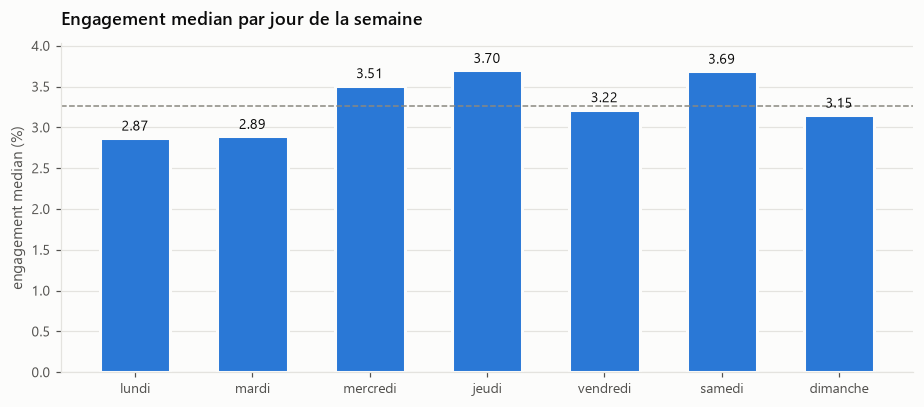

Kruskal-Wallis sur le jour : p = 0.405
-> AUCUN effet significatif


In [12]:
JOURS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
FR = ["lundi", "mardi", "mercredi", "jeudi", "vendredi", "samedi", "dimanche"]
j = u.groupby("nom_jour").taux_engagement.agg(med="median", n="count").reindex(JOURS)

fig, ax = plt.subplots(figsize=(8.5, 3.8))
barres = ax.bar(range(7), j.med, width=0.6, color=C_THEME["art"],
                edgecolor=ink["surface"], linewidth=2)
etiqueter_barres(ax, barres, j.med.values, "{:.2f}", MODE)
ax.axhline(u.taux_engagement.median(), color=ink["muted"], linestyle="--", linewidth=1)
ax.set_xticks(range(7)); ax.set_xticklabels(FR)
finir(ax, "Engagement median par jour de la semaine", None, "engagement median (%)", None, MODE)
plt.tight_layout(); plt.show()

p = stats.kruskal(*[g.taux_engagement.values for _, g in u.groupby("jour_semaine")]).pvalue
print(f"Kruskal-Wallis sur le jour : p = {p:.3f}")
print(f"-> {'effet significatif' if p < 0.05 else 'AUCUN effet significatif'}")

**Le jour de la semaine n'a aucun effet** (p = 0,40). Les sept médianes tiennent dans une
bande de 2,9 % à 3,7 %, ce qui est du bruit à ce volume d'échantillon.

Deuxième conseil populaire démenti. Pour le modèle, l'heure mérite d'être une variable,
le jour probablement pas.

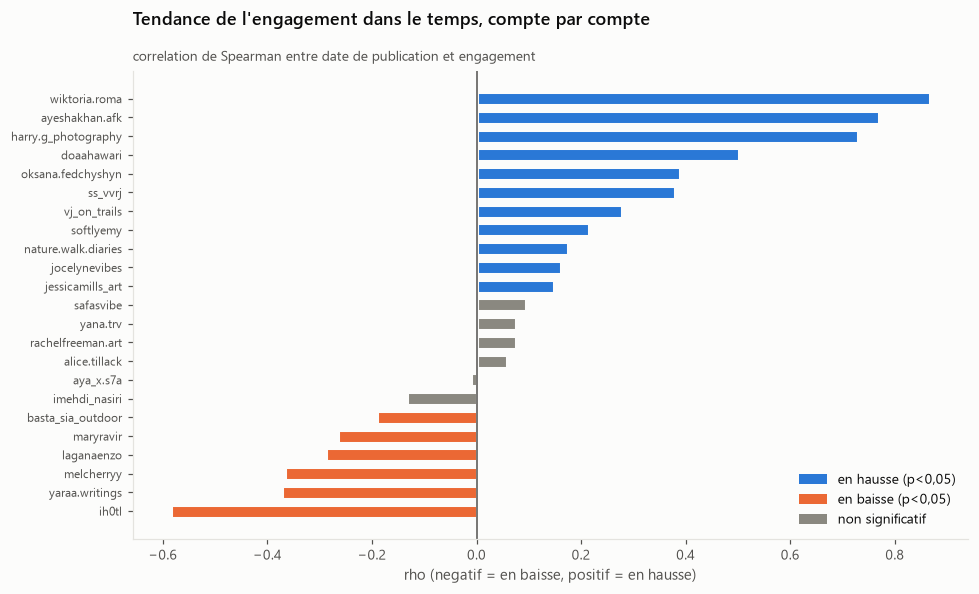

en hausse : 11   en baisse : 6   non significatif : 6


In [13]:
# Tendance interne à chaque compte, sur les comptes ayant au moins 50 posts exploitables
res = []
for c, g in u.groupby("compte"):
    if len(g) < 50:
        continue
    rho, p = stats.spearmanr(g.timestamp.astype("int64"), g.taux_engagement)
    res.append({"compte": c, "posts": len(g), "rho": rho, "p": p})
tend = pd.DataFrame(res).sort_values("rho")

couleurs = [C_TYPE["carrousel"] if (r.rho < 0 and r.p < .05)
            else C_TYPE["image"] if (r.rho > 0 and r.p < .05)
            else ink["muted"] for r in tend.itertuples()]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(range(len(tend)), tend.rho, color=couleurs,
        edgecolor=ink["surface"], linewidth=2, height=0.7)
ax.axvline(0, color=ink["secondary"], linewidth=1)
ax.set_yticks(range(len(tend))); ax.set_yticklabels(tend.compte, fontsize=8)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=C_TYPE["image"], label="en hausse (p<0,05)"),
                   Patch(facecolor=C_TYPE["carrousel"], label="en baisse (p<0,05)"),
                   Patch(facecolor=ink["muted"], label="non significatif")],
          loc="lower right")
finir(ax, "Tendance de l'engagement dans le temps, compte par compte",
      "correlation de Spearman entre date de publication et engagement",
      None, "rho (negatif = en baisse, positif = en hausse)", MODE)
plt.tight_layout(); plt.show()

print(f"en hausse : {((tend.rho > 0) & (tend.p < .05)).sum()}   "
      f"en baisse : {((tend.rho < 0) & (tend.p < .05)).sum()}   "
      f"non significatif : {(tend.p >= .05).sum()}")

11 comptes progressent, 6 reculent, 6 ne montrent rien. Il n'y a donc pas de tendance
générale du marché : chaque compte suit sa propre trajectoire.

**Ce graphique doit être lu avec prudence.** Le dénominateur du taux est le nombre
d'abonnés *actuel*, identique pour tous les posts d'un compte. Un compte qui a beaucoup
grandi a donc des vieux posts mécaniquement pénalisés : ils s'adressaient à une petite
audience mais sont rapportés à l'audience d'aujourd'hui. Une bonne partie des « hausses »
mesure la croissance du compte plutôt qu'une amélioration du contenu.

---
## 4. Effets de compte

Cette partie vérifie que les conclusions précédentes ne sont pas l'artefact de quelques
comptes dominants.

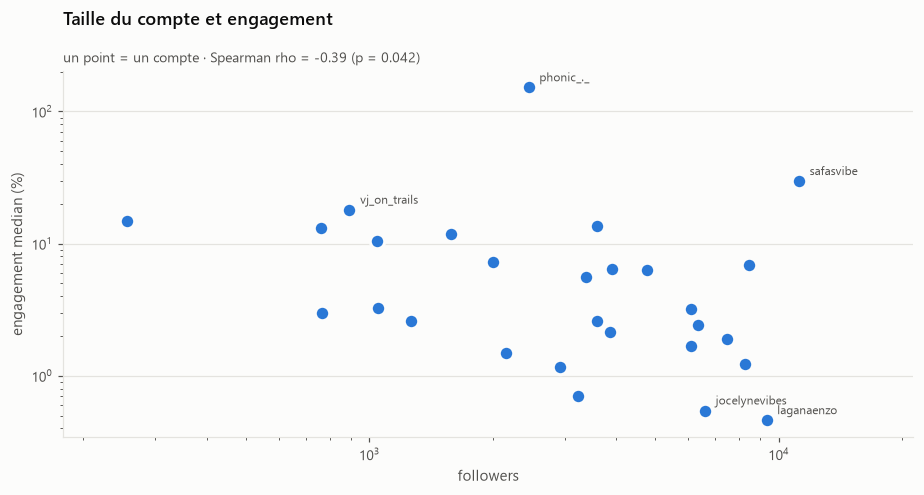

Spearman followers vs engagement median : rho = -0.388, p = 0.0416


In [14]:
parc = u.groupby("compte").agg(
    posts=("id", "count"), followers=("followers", "first"),
    med=("taux_engagement", "median"), theme=("theme", "first")).sort_values("followers")

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.scatter(parc.followers, parc.med, s=90, color=C_THEME["art"],
           edgecolor=ink["surface"], linewidth=2, zorder=3)
ax.set_xscale("log"); ax.set_yscale("log")

# Un seul jeu de couleurs : les comptes atypiques sont nommes directement
for c in parc.nlargest(3, "med").index.tolist() + parc.nsmallest(2, "med").index.tolist():
    r = parc.loc[c]
    ax.annotate(c, (r.followers, r.med), xytext=(7, 4), textcoords="offset points",
                fontsize=8, color=ink["secondary"])

ax.set_xlim(parc.followers.min() * 0.7, parc.followers.max() * 1.9)  # place aux etiquettes

rho, p = stats.spearmanr(parc.followers, parc.med)
finir(ax, "Taille du compte et engagement",
      f"un point = un compte · Spearman rho = {rho:+.2f} (p = {p:.3f})",
      "engagement median (%)", "followers", MODE)
plt.tight_layout(); plt.show()

print(f"Spearman followers vs engagement median : rho = {rho:+.3f}, p = {p:.4f}")

La relation est **négative et significative** (rho = −0,39, p = 0,04) : dans cet
échantillon, plus un compte a d'abonnés, plus son taux d'engagement médian est faible.
C'est un effet connu sur Instagram, et il a deux conséquences directes.

D'abord, le nombre d'abonnés devra être une variable du modèle, sinon celui-ci
attribuera au contenu ce qui vient en réalité de la taille du compte.

Ensuite, cela explique en partie le classement des thèmes vu en partie 1 : les thèmes les
plus « performants » sont ceux qui contiennent le plus de petits comptes.

Deux comptes se détachent très nettement : `phonic_._` (médiane 152 %) et `safasvibe`
(30 %), tous deux portés par des reels viraux. `phonic_._` n'a que 23 posts exploitables
sur 167 collectés, le reste ayant les likes masqués — sa médiane est donc fragile.

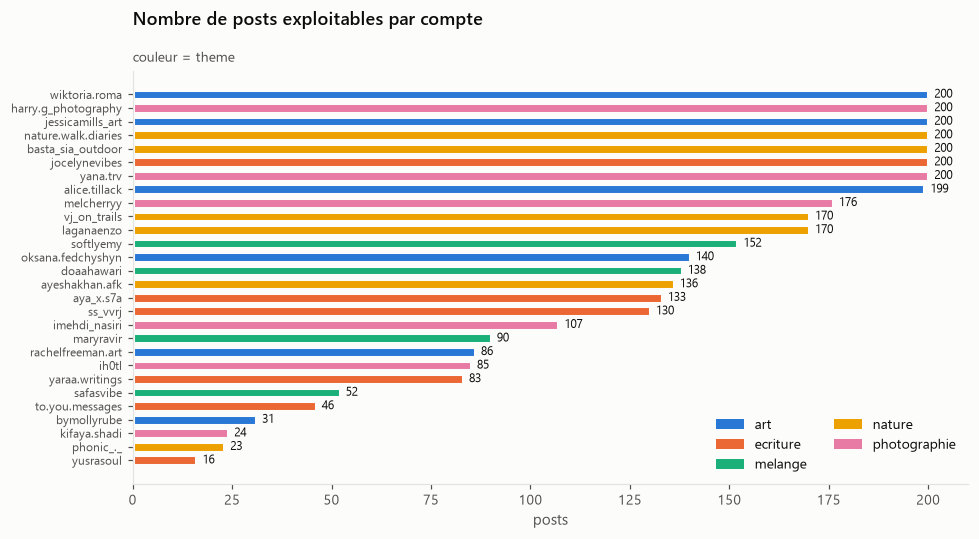

min 16 · median 137 · max 200
part du plus gros compte : 5.6 %


In [15]:
parc_tri = parc.sort_values("posts", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(parc_tri)), parc_tri.posts,
        color=[C_THEME[t] for t in parc_tri.theme],
        edgecolor=ink["surface"], linewidth=2, height=0.72)
ax.set_yticks(range(len(parc_tri))); ax.set_yticklabels(parc_tri.index, fontsize=8)
ax.invert_yaxis()
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)

for i, v in enumerate(parc_tri.posts):
    ax.annotate(str(v), (v, i), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=8, color=ink["primary"])

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=C_THEME[t], label=t) for t in THEMES],
          loc="lower right", ncol=2)
finir(ax, "Nombre de posts exploitables par compte",
      "couleur = theme", None, "posts", MODE)
plt.tight_layout(); plt.show()

print(f"min {parc.posts.min()} · median {int(parc.posts.median())} · max {parc.posts.max()}")
print(f"part du plus gros compte : {parc.posts.max() / parc.posts.sum() * 100:.1f} %")

Le jeu de données est raisonnablement équilibré : aucun compte ne dépasse **5,6 %** du
total, et la médiane est de 137 posts par compte. Le plafond de 200 posts par compte
imposé à la collecte a joué un rôle utile de garde-fou.

Les écarts qui restent viennent des likes masqués, qui frappent très inégalement :
`phonic_._` tombe à 23 posts exploitables, `yusrasoul` à 16.

---
## 5. Bilan chiffré

Ce qui part en modélisation, et comment le jeu est découpé.

In [16]:
print("=== De la collecte au jeu exploitable ===")
print(f"  posts collectes            : {len(df):>5}")
print(f"  - likes masques par l'API  : {-df.likes_masques.sum():>5}")
print(f"  - compte perso (cas usage) : {-(df.groupe_split == 'cas_usage').sum():>5}")
print(f"  = exploitables             : {df.utilisable_entrainement.sum():>5}")

print("\n=== Decoupage train / validation ===")
bilan = u.groupby("groupe_split").agg(comptes=("compte", "nunique"), posts=("id", "count"))
bilan["part_posts_%"] = (bilan.posts / bilan.posts.sum() * 100).round(1)
print(bilan.to_string())

print("\n=== Repartition par theme ===")
print(pd.crosstab(u.theme, u.groupe_split, margins=True, margins_name="total").to_string())

=== De la collecte au jeu exploitable ===
  posts collectes            :  4173
  - likes masques par l'API  :  -567
  - compte perso (cas usage) :   -19
  = exploitables             :  3587

=== Decoupage train / validation ===
              comptes  posts  part_posts_%
groupe_split                              
train              21   2651          73.9
validation          7    936          26.1

=== Repartition par theme ===
groupe_split  train  validation  total
theme                                 
art             656         200    856
ecriture        525          83    608
melange         280         152    432
nature          529         370    899
photographie    661         131    792
total          2651         936   3587


### Ce que retient la phase 2

**Sur les données**

| Élément | Valeur |
|---|---|
| Posts collectés | 4 173 |
| Posts exploitables | 3 587 (86 %) |
| Comptes | 28 (+ 1 cas d'usage) |
| Train | 2 651 posts / 21 comptes |
| Validation | 936 posts / 7 comptes (26 %) |

Le découpage est fait **par compte et non par post** : deux posts d'un même compte
partagent son audience et son style, donc les répartir entre train et validation
ferait fuiter de l'information et gonflerait artificiellement le score.

Contrepartie assumée : la répartition des thèmes est inégale entre les deux groupes
(l'écriture ne pèse que 83 posts en validation). Avec 28 comptes seulement, on ne peut
pas équilibrer à la fois les comptes et les thèmes.

**Sur le contenu**

| Effet | Ampleur |
|---|---|
| Heure de publication | **Forte** — facteur 4,5 entre creux et pic |
| Taille du compte | **Forte** — rho = −0,39, sens inverse |
| Thème du compte | Modérée — rapport 3 entre extrêmes |
| Type de post | Modérée — image > carrousel > vidéo en médiane |
| Nombre de hashtags | Faible — 1 à 5 valent +9 % au-dessus du niveau du compte |
| Longueur de légende | Très faible — environ 1 % de la variation |
| Présence d'emojis | Aucune — p = 0,25 |
| Jour de la semaine | Aucune — p = 0,40 |

**Quatre décisions pour la phase 3**

1. **Modéliser `log(engagement)`**, la distribution étant log-normale.
2. **Inclure le nombre d'abonnés comme variable de contrôle**, faute de quoi le modèle
   attribuera au contenu un effet de taille de compte.
3. **Encoder les hashtags par tranches, pas en compte brut.** L'effet est en cloche :
   une variable linéaire le manquerait entièrement, comme l'a fait la corrélation de
   Spearman ici.
4. **Ne pas compter sur les métadonnées textuelles simples.** Comptages d'emojis et de
   caractères n'expliquent presque rien : la valeur du NLP devra venir du *sens* de la
   légende.

Un mot sur la causalité : tout ce qui précède décrit des **associations**. Rien dans ces
données ne permet d'affirmer qu'ajouter des hashtags ou publier à 15 h *provoque* un
meilleur engagement. Les comptes qui publient au bon moment sont vraisemblablement aussi
ceux qui soignent le reste.

La faiblesse des signaux textuels simples est le vrai enseignement de cette phase :
l'essentiel de la variation reste inexpliqué, et c'est ce que l'image et le contenu
sémantique devront capter en phase 3.